In [7]:
import pandas as pd
from glob import glob
import numpy as np
from numba import njit

from matplotlib import font_manager
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import itertools
import regseq2

from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.patches as mpatches
from matplotlib.cm import ScalarMappable
from matplotlib import collections  as mc
import matplotlib.colors as mcolors

regseq2.viz.matplotlib_style()
regseq2.viz.my_color_dict

from denovo_scanner import build_wt_dict, run_scan, save_outputs, load_df_map

weight = 'regular'
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Lato"],

    "font.weight": weight,        # ticks, text
    "axes.labelweight": weight,   # axis labels
    "axes.titleweight": weight,   # titles
})


In [3]:
df_gc = pd.read_csv("../../data/metadata/growth_conditions_short.csv", delimiter=";")
print(df_gc.tail(5))

    Index             Condition  \
34     37         low phosphate   
35     38  copper sulfate (2mM)   
36     39               acetate   
37     40               nitrate   
38     41   anaerobic + nitrate   

                                          Description  \
34  M9 Minimal Media with 0.5% Glucose to steady s...   
35  M9 Minimal Media with 0.5% Glucose to steady s...   
36          M9 Minimal Media with 0.5% Sodium Acetate   
37  M9 Minimal Media with 0.5% Glucose with 80mM P...   
38  M9 Minimal Media with 0.5% Glucose grown compl...   

                          Group  
34  Nutrient–mineral limitation  
35      Metal & membrane stress  
36                Carbon‐source  
37       Osmotic & ionic stress  
38                    Anaerobic  


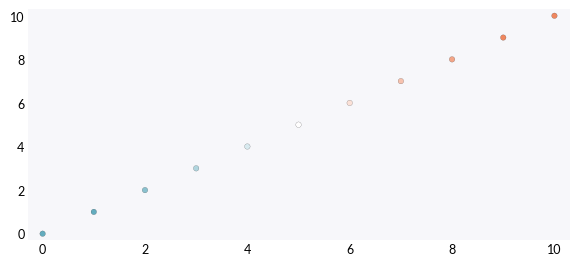

In [38]:
colors_with_points = [
            (0, "#63ACBE"),  
            (0.1, "#63ACBE"),  
            (.5, "#ffffff"),    
            (0.9, "#EF875F"),
            (1, "#EF875F")
        ]


colors_with_points_mi = [
            (0, "#63ACBE"),  
            (0.1, "#63ACBE"),  
            (.5, "#C8C8C8"),    
            (0.9, "#EF875F"),
            (1, "#EF875F")
        ]

my_cmap_mi = LinearSegmentedColormap.from_list("my_cmap", colors_with_points_mi)

my_cmap = LinearSegmentedColormap.from_list("my_cmap", colors_with_points)

plt.scatter(np.arange(11), np.arange(11), color=[my_cmap(x) for x in np.linspace(0, 1, 11)], linewidth=0.1, edgecolor='black')


In [8]:
df_map = pd.read_csv("../../data/mapping/mapped_barcodes_filtered.csv")


# ----------------------------
# Global figure + font settings
# ----------------------------
FIG_WIDTH = 7.0
FIG_HEIGHT = 3.0

mpl.rcParams.update({
    # Figure geometry
    "figure.figsize": (FIG_WIDTH, FIG_HEIGHT),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Fonts
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Lines / markers
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes styling
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    # Mathtext / fonts (no external LaTeX dependency)
    #"mathtext.fontset": "stix",
    #"font.family": "STIXGeneral",
})



In [9]:
df_wt = pd.read_csv("../../data/metadata/wt_sequences.csv")[['promoter_seq', 'promoter']]
wt_dict = dict(zip(df_wt['promoter'].values, df_wt['promoter_seq'].values))
df_wt

,promoter_seq,promoter
0,TTTCATCTTTTGTCAACCATTCACAGCGCAAATATACGCCTTTTTT...,rspAp
1,TCCACATTGATTATTTGCACGGCGTCACACTTTGCTATGCCATAGC...,araBp
2,GTGTTGCACCTCCCCAGAGAGCGGCGGATAATGCTGCGAAAAGAAG...,znuCp
3,CCAGTTTCATCATTCCATTTTATTTTGCGAGCGAGCGCACACTTGT...,xylAp
4,AATTGCGCAACAAAAGTAAGATCTCGGTCATAAATCAAGAAATAAA...,xylFp
...,...,...
112,TGGTGCTGGTTATCAGCACTGAAGGCGACACCGACGTGAAGCACTA...,ygeY_predicted
113,CGCTGGACGAAATCCGCGCCCTGCCTGCAGTACAGAAAGCTAACGC...,hyuA_predicted
114,TCGGACATGTTTGAAGAGATGAAATTTGCCTTCTTTAAACATCGCG...,ygfM_xdhD_predicted
115,AGTGCCAGTTTTTGCGAGGAAGGGGAGTTAGAGACAGGAATTGCGG...,ygfS_ygfT_predicted


In [10]:
files = np.hstack([glob("../../data/extracted_barcodes/*DNA*.txt")])
inds = np.sort([x.split('/')[-1].split('_')[0] for x in files])
inds = [file for file in inds if not np.any([y == file for y in  ['14-3', '15-1', '19-1', '22-1', '25-2', '38-2','4-1', '31-2', '20-2', '13-2', '26-1', '26-2']])]

In [16]:
def get_counts(ind, promoter=None):
    
    # import DNA file
    file_DNA = glob(f"../../data/extracted_barcodes/{ind}*DNA*.txt")[0]
    df_DNA = pd.read_csv(
        file_DNA, 
        names=['ct_0', 'barcode'], sep="\\s+")
    file_RNA = glob(f"../../data/extracted_barcodes/{ind}*RNA*.txt")[0]
    df_RNA = pd.read_csv(
        file_RNA, 
        names=['ct_1', 'barcode'], sep="\\s+")

    # merge files
    df_counts = df_DNA.merge(df_RNA, on="barcode", how='outer').fillna(0)
    df_counts = df_counts.merge(df_map, on="barcode", how='inner')
    
    if promoter == None:
        return df_counts
    elif type(promoter) == str:
        return df_counts[df_counts['name'] == promoter]
    elif type(promoter) == list:
        return df_counts[[x in promoter for x in df_counts['name'].values]]
        


In [28]:
@njit
def compare_string_bytes_equal(s1, s2):
    """
    Returns 1 where bases are equal, 0 where they differ.
    """
    n = len(s1)
    if n != len(s2):
        raise ValueError("Strings must have the same length")
    result = np.empty(n, dtype=np.int64)
    for i in range(n):
        result[i] = 1 if s1[i] == s2[i] else 0
    return result


@njit
def safe_log2(x):
    return np.log(x) / np.log(2.0)


@njit
def mi_from_joint_2x2(joint):
    """
    joint: shape (2,2), sums to 1
    """
    px0 = joint[0, 0] + joint[0, 1]
    px1 = joint[1, 0] + joint[1, 1]
    pz0 = joint[0, 0] + joint[1, 0]
    pz1 = joint[0, 1] + joint[1, 1]

    mi = 0.0
    # (x,z) in {0,1}x{0,1}
    for x in range(2):
        for z in range(2):
            p = joint[x, z]
            if p <= 0.0:
                continue
            px = px0 if x == 0 else px1
            pz = pz0 if z == 0 else pz1
            if px <= 0.0 or pz <= 0.0:
                continue
            mi += p * safe_log2(p / (px * pz))
    return mi


@njit
def h2(p):
    """
    Bernoulli entropy in bits.
    """
    if p <= 0.0 or p >= 1.0:
        return 0.0
    return -p * safe_log2(p) - (1.0 - p) * safe_log2(1.0 - p)


def _transform_counts(c, transform="raw"):
    c = c.astype(np.float64)
    if transform == "raw":
        return c
    if transform == "sqrt":
        return np.sqrt(c)
    if transform == "log1p":
        return np.log1p(c)
    if transform.startswith("pow:"):
        a = float(transform.split(":")[1])
        return np.power(c, a)
    if transform.startswith("clip:"):
        k = float(transform.split(":")[1])
        return np.minimum(c, k)
    raise ValueError(f"Unknown transform: {transform}")


def compute_MI(
    ind,
    promoter_list=None,
    *,
    transform="sqrt",            # "raw"|"sqrt"|"log1p"|"pow:0.5"|"clip:200"
    barcode_equal=False,        # each barcode contributes total weight 1
    require_both_counts=False,   # filter to ct_0>0 & ct_1>0
    positions=None,             # override length/pos axis if needed
    normalize_by_entropy=False, # MI / min(H(X_i), H(Z))
):
    df_counts = get_counts(ind, promoter_list)
    df_out = []

    for promoter, gdf in df_counts.groupby("name"):
        if promoter in ["galEp", "ybeDp2"]:
            continue

        wt_seq = wt_dict[promoter]

        # (n_barcodes, L) array: 1 if base == WT at position
        is_match = np.vstack([
            np.array(compare_string_bytes_equal(wt_seq.encode("ascii"), s.encode("ascii")))
            for s in gdf["promoter"].astype(str).values
        ]).astype(np.int64)

        n, L = is_match.shape

        # optional filtering
        if require_both_counts:
            idx = (gdf["ct_0"].values > 0) & (gdf["ct_1"].values > 0)
        else:
            idx = np.ones(len(gdf), dtype=bool)

        is_match = is_match[idx, :]
        x_raw = gdf["ct_0"].values[idx]
        y_raw = gdf["ct_1"].values[idx]

        # transform counts (weighting choice)
        x = _transform_counts(x_raw, transform=transform)
        y = _transform_counts(y_raw, transform=transform)

        # per-barcode equalization: each barcode has total weight 1 (after transform)
        if barcode_equal:
            denom = x + y
            denom = np.where(denom > 0, denom, 1.0)
            x = x / denom
            y = y / denom

        total = np.sum(x + y)
        if total <= 0:
            continue

        # Build joint weights per position:
        # z index: 0=DNA, 1=RNA
        # x-state index: 0=match(WT), 1=mismatch(mut)
        #
        # We'll store joint as joint[pos, x_state, z]
        # Your original p[pos, z, x_state] is equivalent; this is just clearer.
        joint = np.zeros((L, 2, 2), dtype=np.float64)

        # match (WT at that base)
        joint[:, 0, 0] = is_match.T @ x
        joint[:, 0, 1] = is_match.T @ y

        # mismatch (mutated at that base)
        mismatch = 1 - is_match
        joint[:, 1, 0] = mismatch.T @ x
        joint[:, 1, 1] = mismatch.T @ y

        # normalize to probabilities
        joint /= total

        # MI per position
        mi = np.empty(L, dtype=np.float64)
        for i in range(L):
            mi[i] = mi_from_joint_2x2(joint[i, :, :])

        if normalize_by_entropy:
            # H(Z) is global (same for all positions)
            pz_dna = np.sum(joint[:, :, 0]) / L  # average across positions (should equal DNA mass)
            # better: compute directly from weights:
            # pz_dna = np.sum(x)/total ; pz_rna = np.sum(y)/total
            pz_dna = np.sum(x) / total
            Hz = h2(pz_dna)

            mi_norm = np.empty(L, dtype=np.float64)
            for i in range(L):
                px_mut = joint[i, 1, 0] + joint[i, 1, 1]  # P(X=mut) at pos i
                Hx = h2(px_mut)
                denom = min(Hx, Hz)
                mi_norm[i] = mi[i] / denom if denom > 0 else 0.0
        else:
            mi_norm = None

        # position axis
        if positions is None:
            pos = np.arange(L)
        else:
            if len(positions) != L:
                raise ValueError("positions length must match sequence length")
            pos = np.asarray(positions)

        out = pd.DataFrame({
            "promoter": promoter,
            "pos": pos,
            "mut_info": mi,
            "N": np.full(L, is_match.shape[0], dtype=float),
            "N_reads": np.full(L, total, dtype=float),
            "N_seqs": np.full(L, gdf["promoter"].nunique(), dtype=float),
            "ind": ind,
            "transform": transform,
            "barcode_equal": barcode_equal,
            "require_both_counts": require_both_counts,
        })
        if mi_norm is not None:
            out["mut_info_norm"] = mi_norm

        df_out.append(out)

    return pd.concat(df_out, ignore_index=True) if df_out else pd.DataFrame()

In [29]:
# Precompute the mapping outside the function
DNA_MAPPING = np.zeros(256, dtype=np.uint8)
DNA_MAPPING[ord('A')] = 0
DNA_MAPPING[ord('C')] = 1
DNA_MAPPING[ord('G')] = 2
DNA_MAPPING[ord('T')] = 3

def dna_to_int(seq, mapping=DNA_MAPPING):
    # Convert the sequence to a numpy array of its ASCII codes.
    arr = np.frombuffer(seq.encode('ascii'), dtype=np.uint8)
    return mapping[arr]


def batch_dna_to_int(sequences, mapping=DNA_MAPPING):
    # Assume all sequences are the same length.
    n = len(sequences[0])
    # Create a 2D array of shape (num_sequences, n)
    seq_arr = np.empty((len(sequences), n), dtype=np.uint8)
    for i, seq in enumerate(sequences):
        seq_arr[i, :] = np.frombuffer(seq.encode('ascii'), dtype=np.uint8)
    return mapping[seq_arr]


@njit
def accumulate_shifts(int_seq, is_mut, exp_diff, ex_shift_arr):
    num_variants, seq_len = int_seq.shape
    for i in range(num_variants):
        for j in range(seq_len):
            base = int_seq[i, j]
            ex_shift_arr[j, base] += exp_diff[i] * is_mut[i, j]


positions = list(itertools.product(range(-115, 45), range(1, 5)))

def compute_es(ind, promoter_list=None):
    # import DNA file
    df_counts = get_counts(ind)
    Lambda = np.median((df_counts['ct_1'].values + 1) / (df_counts['ct_0'].values + 1))

    if promoter_list == None:
        promoter_list = df_counts['name'].unique()
    elif type(promoter_list) == str:
        promoter_list = [promoter_list]
    # iterate through promoters
    df_out_arr = [] 

    for promoter in promoter_list:
        gdf = df_counts[df_counts['name'] == promoter]
        if promoter in ['galEp', 'ybeDp2']:
            continue
        # find where the mutations are
        wt_seq = wt_dict[promoter]
        is_mut = 1 - np.vstack([np.array(compare_string_bytes_equal(wt_seq.encode("ascii"), x.encode("ascii"))) for x in gdf['promoter'].values])
        int_seq = batch_dna_to_int(gdf['promoter'].values)

        # compute relative counts and difference to mean
        relative_counts = (gdf['ct_1'].values + 1) / (gdf['ct_0'].values + 1)
        mean_rel_counts = np.mean(relative_counts)
        exp_diff = relative_counts - mean_rel_counts
        
        # initialize expression shift array
        ex_shift_arr = np.zeros((160, 4))

        # fill array
        accumulate_shifts(int_seq, is_mut, exp_diff, ex_shift_arr)

        # get wild type base column for dataframe
        ind_wt = list(itertools.product(list(wt_seq), range(1, 5)))

        # fill dataframe 
        df_out_arr.append(pd.DataFrame({"promoter": promoter, 
                                          "expression_shift": 1/Lambda * np.ravel(ex_shift_arr).T, 
                                          "pos":[t[0] for t in positions],
                                          "base":[t[1] for t in positions],
                                          "wt_base":[t[0] for t in ind_wt],
                                          "ind": ind
                                         }))

    return pd.concat(df_out_arr)
    


In [30]:
def plot_exshift(promoter, ind, paper=False, xscale=1):

    
    df = compute_es(ind, promoter)
    plt.rcParams['pdf.compression'] = False
    # data dimensions
    data = np.reshape(df['expression_shift'].values, [160, 4]).T
    rows, cols = data.shape

    # Determine symmetric normalization centered at zero
    max_abs_val = np.max(np.abs(df['expression_shift'].values))
    norm = Normalize(vmin=-max_abs_val, vmax=max_abs_val)
    # set figure size proportional to data dimensions
    _y = 7*xscale/cols
    fig_width = cols * _y/xscale  # adjust 0.2 as needed for scaling
    fig_height = rows * _y
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

   # Iterate and draw rectangles colored by expression_shift
    for _, row in df.iterrows():
        # Normalize the value to [0,1] for colormap
        norm_value = norm(row['expression_shift'])
        color = my_cmap(norm_value)
        
        rect = mpatches.Rectangle(
            (row['pos']/xscale-0.5/xscale, row['base']-0.5), 1/xscale, 1,
            linewidth=0, facecolor=color
        )
        ax.add_patch(rect)

    

    # Create a ScalarMappable for the colorbar
    sm = ScalarMappable(norm=norm, cmap=my_cmap)
    sm.set_array([])  # required for older matplotlib versions

    # Add colorbar
    # cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    # cbar.set_label("Expression shift\nlog2 fold change", fontsize=8)
    # cbar.ax.tick_params(labelsize=8)

    # Set axis limits
    ax.set_xlim(-115.5/xscale, 44.5/xscale)
    ax.set_ylim(0.5, 4.5)

    # Calculate figsize in inches
    ax.set_yticks([1, 2, 3, 4], ['A', 'C', 'G', 'T'], fontsize=8)
    ax.set_xticks(np.arange(-110, 41, step=10)/xscale, np.arange(-110, 41, step=10), fontsize=8)
    ax.grid(False)
    return fig, ax



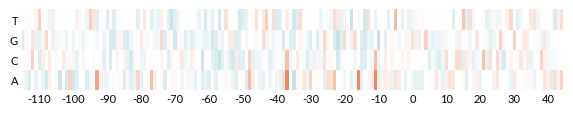

In [31]:
fig, ax = plot_exshift("araBp", '3-2', xscale=6)

In [32]:
files = np.hstack([glob("../../data/extracted_barcodes/*DNA*.txt")])
inds = np.sort([x.split('/')[-1].split('_')[0] for x in files])
inds = [file for file in inds if not np.any([y == file for y in  ['14-3', '15-1', '19-1', '22-1', '25-2', '38-2','4-1', '31-2', '20-2', '13-2', '26-1', '26-2']])]

<BarContainer object of 160 artists>

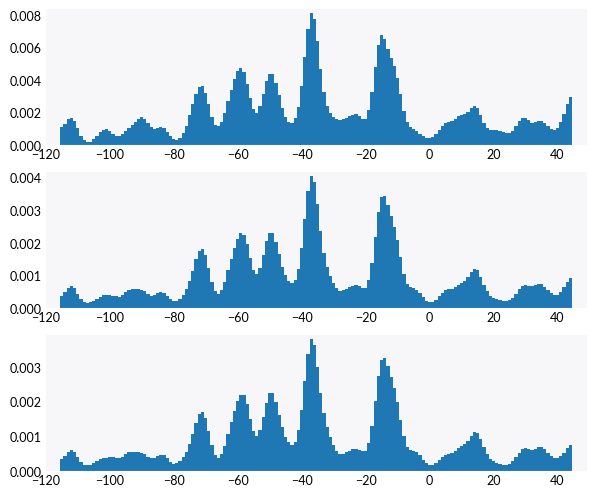

In [33]:
fig, ax = plt.subplots(3, 1, figsize=(FIG_WIDTH, 6))


x1 = compute_MI('3-1', 'araBp',transform='raw')['mut_info'].values
x2 = compute_MI('3-1', 'araBp',transform='sqrt')['mut_info'].values
x3 = compute_MI('3-1', 'araBp',transform='log1p')['mut_info'].values

ax[0].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x1, 2), width=1)
ax[1].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x2, 2), width=1)
ax[2].bar(np.arange(-115, 45), scipy.ndimage.gaussian_filter1d(x3, 2), width=1)

In [34]:
df_list = []
for ind in inds:
    print(ind)
    df_list.append(compute_MI(ind))




1-1
1-2
10-1
10-2
11-1
11-2
12-1
12-2
13-1
13-3
14-1
14-2
15-2
15-3
16-1
16-2
17-1
17-2
18-1
18-2
19-2
19-3
2-1
2-2
20-1
20-3
21-1
21-2
22-2
22-3
23-1
23-2
24-1
24-2
25-1
25-3
28-1
28-2
29-1
29-2
3-1
3-2
30-1
30-2
31-1
31-3
32-1
32-2
33-1
33-2
34-1
34-2
35-1
35-2
36-1
36-2
37-1
37-2
38-1
38-3
39-1
39-2
4-2
4-3
40-1
40-2
40-3
41-1
41-2
5-1
5-2
6-1
6-2
7-1
7-2
8-1
8-2
9-1
9-2


In [42]:
df_all = pd.concat(df_list).groupby(['promoter', 'N', 'ind', 'N_seqs', 'N_reads'])['mut_info'].agg('max').reset_index()
df_mi = pd.concat(df_list)
df_mi.to_csv("mi_all.csv")

In [43]:
df_list = []
for ind in inds:
    print(ind)
    df_list.append(compute_es(ind))

df_ex = pd.concat(df_list)
df_ex.to_csv("ex_all.csv")

1-1
1-2
10-1
10-2
11-1
11-2
12-1
12-2
13-1
13-3
14-1
14-2
15-2
15-3
16-1
16-2
17-1
17-2
18-1
18-2
19-2
19-3
2-1
2-2
20-1
20-3
21-1
21-2
22-2
22-3
23-1
23-2
24-1
24-2
25-1
25-3
28-1
28-2
29-1
29-2
3-1
3-2
30-1
30-2
31-1
31-3
32-1
32-2
33-1
33-2
34-1
34-2
35-1
35-2
36-1
36-2
37-1
37-2
38-1
38-3
39-1
39-2
4-2
4-3
40-1
40-2
40-3
41-1
41-2
5-1
5-2
6-1
6-2
7-1
7-2
8-1
8-2
9-1
9-2


In [45]:
df_mi = pd.read_csv("mi_all.csv", index_col=0)
df_ex = pd.read_csv("ex_all.csv", index_col=0)

relabel = True
if relabel == True: 
    df_mi['ind'] = df_mi['ind'].replace({'20-1': '30-1', '30-1': '20-1'})
    df_ex['ind'] = df_ex['ind'].replace({'20-1': '30-1', '30-1': '20-1'})

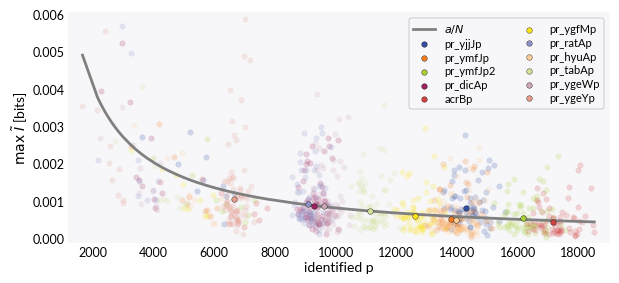

In [46]:
tss_names = {
    "TSS_1414_storz_regulondb": 'pr_yahMp',
    'TSS_18061_regulondb': 'pr_yjjJp',
    'TSS_4654_wanner_regulondb': 'pr_ymfJp',
    'TSS_4655_regulondb': 'pr_ymfJp2',
    'TSS_6311_regulondb': 'pr_dicAp',
    'ygfM_xdhD_predicted': 'pr_ygfMp',
    'ratA_yfjF_predicted': 'pr_ratAp',
    'hyuA_predicted': 'pr_hyuAp',
    'tabA_predicted': 'pr_tabAp',
    'ygeW_predicted': 'pr_ygeWp',
    'ygeY_predicted': 'pr_ygeYp',


}
proms = [
    'TSS_18061_regulondb', 
    'TSS_4654_wanner_regulondb', 
    'TSS_4655_regulondb', 
    'TSS_6311_regulondb', 
    'acrBp', 
    'ygfM_xdhD_predicted', 
    'ratA_yfjF_predicted',
    'hyuA_predicted',
    'tabA_predicted',
    'ygeW_predicted',
    'ygeY_predicted'
    ]#, 'ygfS_ygfT_predicted']



_df = df_all[[x in proms for x in df_all['promoter']]]
fig, ax = plt.subplots(figsize=(7, 3))
# Transform data to linear form: y = a * (1/x)
# We solve A*p = y, where A is the column (1/x)
x = _df['N'].values
y = _df['mut_info'].values
A = (1/x)[:, np.newaxis]
a, residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)
ax.plot(np.sort(x), a[0]/np.sort(x), color='gray', linewidth=2, label=r'$a/N$')

colors = [regseq2.viz.my_color_dict['blue1'],
          regseq2.viz.my_color_dict['orange1'],
          regseq2.viz.my_color_dict['green1'],
          regseq2.viz.my_color_dict['purple1'],
          regseq2.viz.my_color_dict['red1'],
          regseq2.viz.my_color_dict['yellow1'],
          regseq2.viz.my_color_dict['blue2'],
          regseq2.viz.my_color_dict['orange2'],
          regseq2.viz.my_color_dict['green2'],
          regseq2.viz.my_color_dict['purple2'],
          regseq2.viz.my_color_dict['red2']
          ]


for (c, prom) in zip(colors, proms):
    x = _df[_df['promoter'] == prom]['N'].values
    y = _df[_df['promoter'] == prom]['mut_info'].values
    ax.scatter(x, y, alpha=0.2, color=c)

    x_mean = np.median(_df[_df['promoter'] == prom]['N'].values)
    y_mean = np.median(_df[_df['promoter'] == prom]['mut_info'].values)

    if prom in tss_names.keys():
        label=tss_names[prom]
    else:
        label=prom

    ax.scatter(x_mean, y_mean, label=label, color=c, edgecolors='black', zorder=3)
#     


ax.set_ylabel(r'$\mathrm{max}\ \tilde{I}$ [bits]')
ax.set_xlabel('identified p')
#ax.set_yscale('log')
ax.legend(fontsize=8, ncols=2)
#fig.savefig('../figures/MI_N_scaling_noisy.pdf')

In [47]:
a

array([8.13907748])

(-116.0, 45.0)

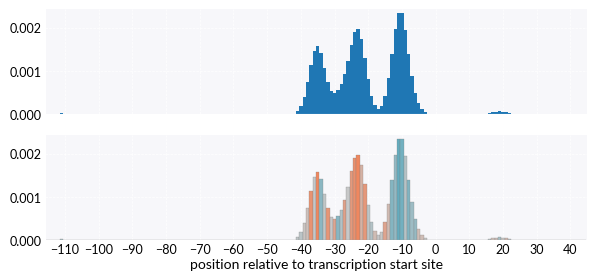

In [49]:
sigma = 2
fig, ax = plt.subplots(2, 1, figsize=(7, 3))

N = df_mi[df_mi['promoter'] == 'tisBp']['N'].values[0]
x = scipy.ndimage.gaussian_filter1d(np.maximum(df_mi[(df_mi['promoter'] == 'tisBp') & (df_mi['ind'] == '3-2')]['mut_info'].values -a/N, np.zeros(160)), sigma)

ax[0].bar(np.arange(-115, 45), x, width=1)

df_sum = df_ex[df_ex['promoter'] == 'tisBp'].groupby(['pos'])['expression_shift'].agg(sum).reset_index()
max_abs_val = np.max(np.abs(df_sum['expression_shift'].values/3))
norm = Normalize(vmin=-max_abs_val, vmax=max_abs_val)

color = [my_cmap_mi(norm(x)) for x in df_sum['expression_shift'].values/3]
ax[1].bar(np.arange(-115, 45), x, width=1, color=color, edgecolor='gray', linewidth=0.2)


ax[0].set_xticks(np.arange(-110, 41, step=10), [])
ax[1].set_xticks(np.arange(-110, 41, step=10))
ax[1].set_xlabel("position relative to transcription start site")

ax[0].grid(True, linewidth=0.5, color="white", linestyle="--")
ax[1].grid(True, linewidth=0.5, color="white", linestyle="--")

ax[0].set_xlim(-116, 45)
ax[1].set_xlim(-116, 45)
#fig.savefig('../figures/tisBp_arabinose_footprint.pdf')

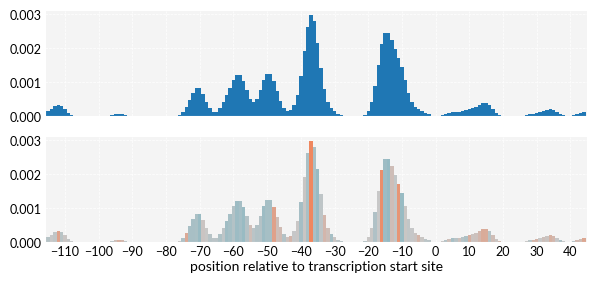

In [37]:
sigma = 2
fig, ax = plt.subplots(2, 1, figsize=(7, 3))

N = df_mi[df_mi['promoter'] == 'araBp']['N'].values[0]
x = scipy.ndimage.gaussian_filter1d(np.maximum(df_mi[df_mi['promoter'] == 'araBp']['mut_info'].values - a/N, np.zeros(160)), sigma)

ax[0].bar(np.arange(-115, 45), x, width=1)

df_sum = df_ex[df_ex['promoter'] == 'araBp'].groupby(['pos'])['expression_shift'].agg(sum).reset_index()
max_abs_val = np.max(np.abs(df_sum['expression_shift'].values/3))
norm = Normalize(vmin=-max_abs_val, vmax=max_abs_val)

color = [my_cmap_mi(norm(x)) for x in df_sum['expression_shift'].values/3]
ax[1].bar(np.arange(-115, 45), x, width=1, color=color)#, edgecolor='gray', linewidth=0.2)


ax[0].set_xticks(np.arange(-110, 41, step=10), [])
ax[1].set_xticks(np.arange(-110, 41, step=10))
ax[1].set_xlabel("position relative to transcription start site")

ax[0].grid(True, linewidth=0.5, color="white", linestyle="--")
ax[1].grid(True, linewidth=0.5, color="white", linestyle="--")

ax[0].set_xlim(-116, 45)
ax[1].set_xlim(-116, 45)
fig.savefig('../figures/araBp_arabinose_footprint.pdf')

CpxR

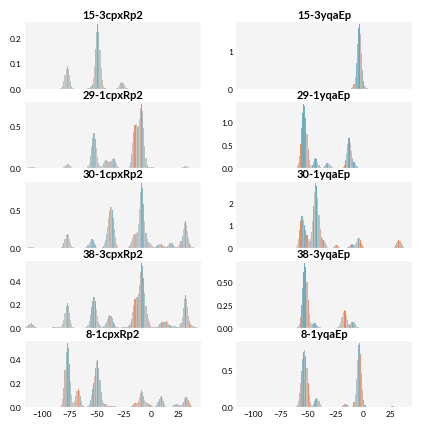

In [492]:
promoter = ['cpxRp2', 'yqaEp']
conditions = ['29-1', '30-1', '38-3', '15-3', '8-1']

df_mi_temp = df_mi[[x in promoter for x in df_mi['promoter'].values]].sort_values(by=['ind', 'promoter'])
df_mi_temp = df_mi_temp[[x in conditions for x in df_mi_temp['ind'].values]]
df_ex_temp = df_ex[[x in promoter for x in df_ex['promoter'].values]].sort_values(by=['ind', 'promoter'])
df_ex_temp = df_ex_temp[[x in conditions for x in df_ex_temp['ind'].values]]



sigma = 2
fig, ax = plt.subplots(5, 2, figsize=(5, 5), sharex=True)#, sharey=True)

n = 0
ax_arr = np.ravel(ax.T)
for i, ((prom, ), gdf) in enumerate(df_mi_temp.sort_values(by=['ind', 'promoter']).groupby(['promoter'])):
    for j, ((ind, ), ggdf) in enumerate(gdf.groupby(['ind'])):
        N = ggdf['N'].values[0]

        x = scipy.ndimage.gaussian_filter1d(np.maximum(ggdf['mut_info'].values - a/N, np.zeros(160)), sigma)

        df_sum = df_ex_temp[(df_ex_temp['promoter'] == prom) & (df_ex_temp['ind'] == ind)].groupby(['pos'])['expression_shift'].agg(sum).reset_index()
        max_abs_val = np.max(np.abs(df_sum['expression_shift'].values/3))
        norm = Normalize(vmin=-max_abs_val, vmax=max_abs_val)

        color = [my_cmap_mi(norm(x)) for x in df_sum['expression_shift'].values/3]
        ax_arr[n].bar(np.arange(-115, 45), x*1000, width=1, color=color)#, linewidth=0.1, edgecolor='#CCCCCC')
        ax_arr[n].set_xlim(-116, 45)
        ax_arr[n].tick_params(axis='both', which='major', labelsize=6)
        ax_arr[n].set_title(ind +prom)
        #ax_arr[n].set_xlim(-60, 20)
        #ax[i, j].set_xticks(np.arange(-60, 21, step=20))
        n += 1

# for i_ax, _ax in enumerate(ax.flat):
#     if i_ax // 3 != 4:  # not in last row (5 rows, index 4)
#         _ax.tick_params(axis='x', labelbottom=False)


fig.savefig(f'../figures/cpxR.pdf')

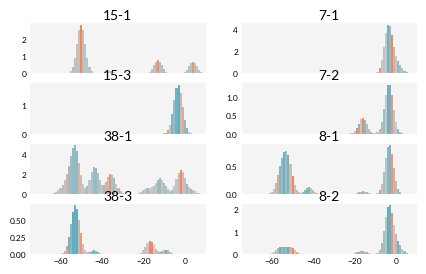

In [111]:
sigma = 2
fig, ax = plt.subplots(4, 2, figsize=(5, 3), sharex=True)#, sharey=True)

n = 0
ax_arr = np.ravel(ax.T)
for i, ((prom, ), gdf) in enumerate(df_mi_yqaE.groupby(['promoter'])):
    for j, ((ind, ), ggdf) in enumerate(gdf.groupby(['ind'])):
        N = ggdf['N'].values[0]

        x = scipy.ndimage.gaussian_filter1d(np.maximum(ggdf['mut_info'].values - a/N, np.zeros(160)), sigma)

        df_sum = df_ex_yqaE[(df_ex_yqaE['promoter'] == prom) & (df_ex_yqaE['ind'] == ind)].groupby(['pos'])['expression_shift'].agg(sum).reset_index()
        max_abs_val = np.max(np.abs(df_sum['expression_shift'].values/3))
        norm = Normalize(vmin=-max_abs_val, vmax=max_abs_val)

        color = [my_cmap_mi(norm(x)) for x in df_sum['expression_shift'].values/3]
        ax_arr[n].bar(np.arange(-115, 45), x*1000, width=1, color=color)#, linewidth=0.1, edgecolor='#CCCCCC')
        ax_arr[n].set_xlim(-116, 45)
        ax_arr[n].tick_params(axis='both', which='major', labelsize=6)
        ax_arr[n].set_title(ind)
        ax_arr[n].set_xlim(-75, 10)
        #ax[i, j].set_xticks(np.arange(-60, 21, step=20))
        n += 1

# for i_ax, _ax in enumerate(ax.flat):
#     if i_ax // 3 != 4:  # not in last row (5 rows, index 4)
#         _ax.tick_params(axis='x', labelbottom=False)


fig.savefig('../figures/yqaE_footprints.pdf')

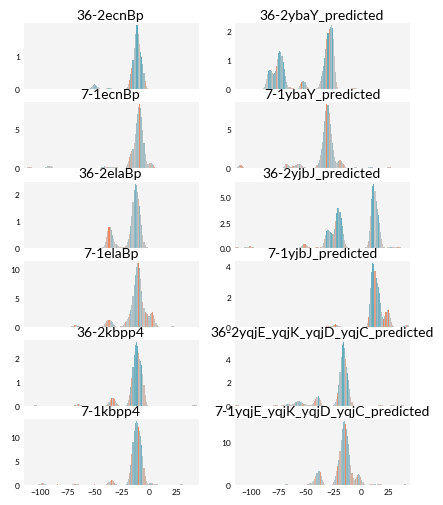

In [20]:
promoter = ['yjbJ_predicted', 'ybaY_predicted', 'yqjE_yqjK_yqjD_yqjC_predicted', 'kbpp4', 'ecnBp', 'elaBp'] 
conditions = ['7-1', '36-2']
df_mi_temp = df_mi[[x in promoter for x in df_mi['promoter'].values]].sort_values(by=['ind', 'promoter'])
df_mi_temp = df_mi_temp[[x in conditions for x in df_mi_temp['ind'].values]]
df_ex_temp = df_ex[[x in promoter for x in df_ex['promoter'].values]].sort_values(by=['ind', 'promoter'])
df_ex_temp = df_ex_temp[[x in conditions for x in df_ex_temp['ind'].values]]



sigma = 2
fig, ax = plt.subplots(6, 2, figsize=(5, 6), sharex=True)#, sharey=True)
a = 8.13
n = 0
ax_arr = np.ravel(ax.T)
for i, ((prom, ), gdf) in enumerate(df_mi_temp.sort_values(by=['ind', 'promoter']).groupby(['promoter'])):
    for j, ((ind, ), ggdf) in enumerate(gdf.groupby(['ind'])):
        N = ggdf['N'].values[0]

        x = scipy.ndimage.gaussian_filter1d(np.maximum(ggdf['mut_info'].values - a/N, np.zeros(160)), sigma)

        df_sum = df_ex_temp[(df_ex_temp['promoter'] == prom) & (df_ex_temp['ind'] == ind)].groupby(['pos'])['expression_shift'].agg(sum).reset_index()
        max_abs_val = np.max(np.abs(df_sum['expression_shift'].values/3))
        norm = Normalize(vmin=-max_abs_val, vmax=max_abs_val)

        color = [my_cmap_mi(norm(x)) for x in df_sum['expression_shift'].values/3]
        ax_arr[n].bar(np.arange(-115, 45), x*1000, width=1, color=color)#, linewidth=0.1, edgecolor='#CCCCCC')
        ax_arr[n].set_xlim(-116, 45)
        ax_arr[n].tick_params(axis='both', which='major', labelsize=6)
        ax_arr[n].set_title(ind +prom)
        #ax_arr[n].set_xlim(-60, 20)
        #ax[i, j].set_xticks(np.arange(-60, 21, step=20))
        n += 1

# for i_ax, _ax in enumerate(ax.flat):
#     if i_ax // 3 != 4:  # not in last row (5 rows, index 4)
#         _ax.tick_params(axis='x', labelbottom=False)


fig.savefig(f'../figures/salt_footprints.pdf')